**EDA-Baseline Model**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
import os
import time

In [2]:
sns.set_theme(style="whitegrid")

df_train = pd.read_csv("../../data/train_prices_decisions_2025.csv")

count    50000.000000
mean        75.590536
std         81.329851
min          0.010000
25%         35.267257
50%         56.080048
75%         80.798568
max        452.339045
Name: price_item, dtype: float64
count    24881.000000
mean        39.707721
std         30.532608
min          0.010000
25%         22.034983
50%         37.041705
75%         52.673926
max        381.643294
Name: price_item, dtype: float64


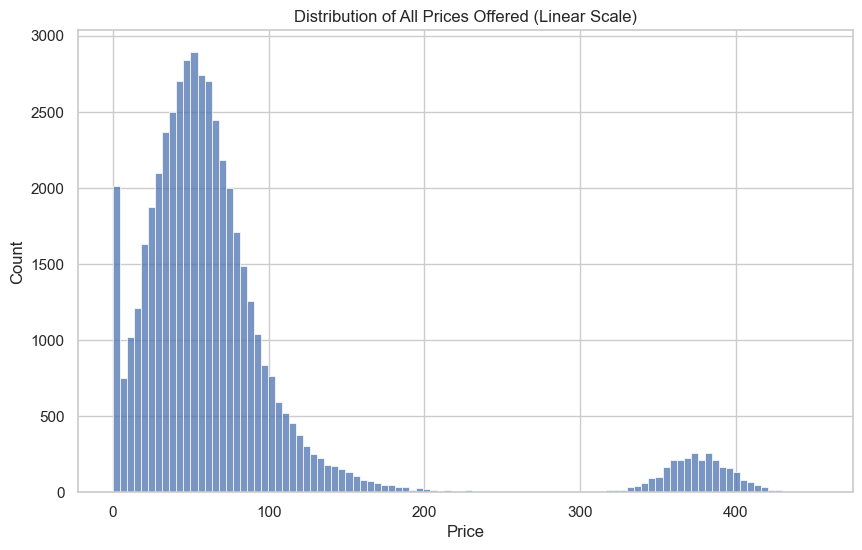

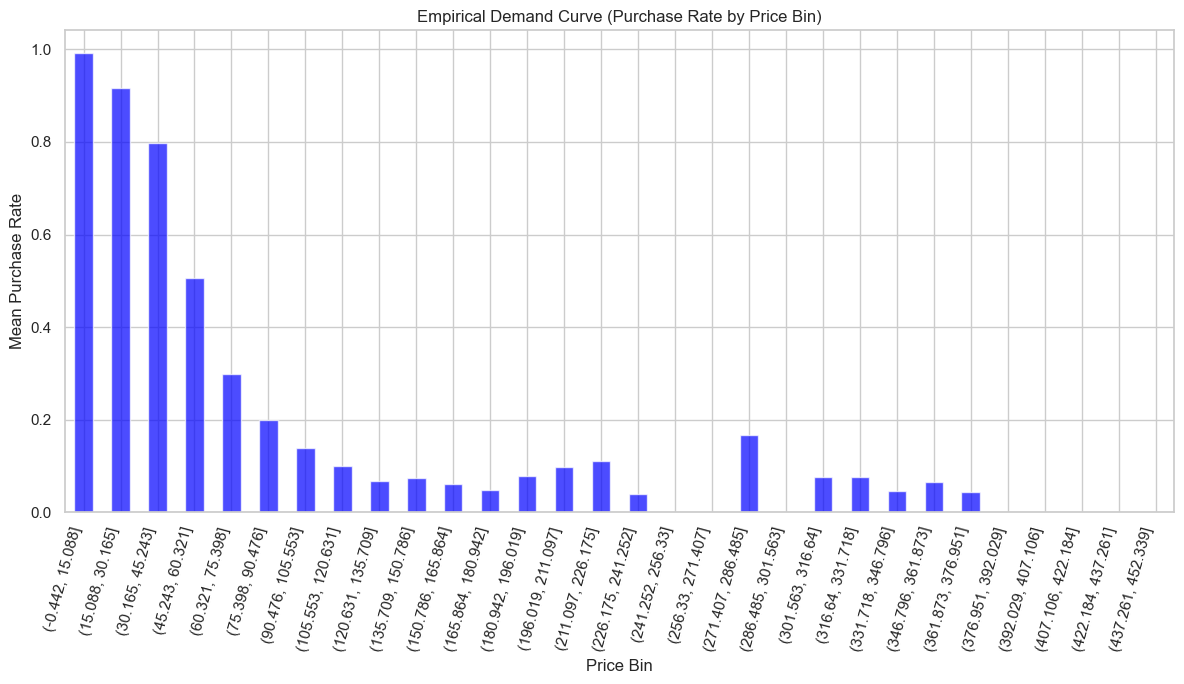

In [3]:
print(df_train['price_item'].describe())

sales_df = df_train[df_train['item_bought'] == True]
print(sales_df['price_item'].describe())

plt.figure(figsize=(10, 6))
sns.histplot(df_train['price_item'], kde=False, bins=100)
plt.title('Distribution of All Prices Offered (Linear Scale)')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

df_train['price_bin'] = pd.cut(df_train['price_item'], bins=30)
demand_curve = df_train.groupby('price_bin', observed=True)['item_bought'].mean()
plt.figure(figsize=(12, 7))
demand_curve.plot(kind='bar', color='blue', alpha=0.7)
plt.title('Empirical Demand Curve (Purchase Rate by Price Bin)')
plt.xlabel('Price Bin')
plt.ylabel('Mean Purchase Rate')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# 1. Define the "Sweet Spot" (Dense Search)
#    Our EDA showed 75% of all prices *offered* were at or below $80.79.
#    We create a dense search in this $0-$80 region, using 160 checks.
dense_range = np.linspace(0, 80, 160)

# 2. Define the "Outlier Zone" (Sparse Search)
#    Our EDA on *successful* sales showed the max price paid was $381.64.
#    We use a sparse search (40 checks) to cover this $81-$387 range.
sparse_range = np.linspace(81, 387, 40)

# 3. Combine them into our final price grid
prices_to_check = np.concatenate([dense_range, sparse_range])

**Grid Search**

In [1]:
MODEL_PATH = 'xgb_model.pkl'
TEST_DATA_PATH = '../../data/test_user_info_2025.csv'
OUTPUT_CSV_PATH = '../static_prices_submission.csv'

In [4]:
with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)

test_users = pd.read_csv(TEST_DATA_PATH)

In [7]:
df_grid = test_users.loc[test_users.index.repeat(len(prices_to_check))].reset_index(drop=True)
df_grid['price_item'] = np.tile(prices_to_check, len(test_users))

features = ['Covariate1', 'Covariate2', 'Covariate3', 'price_item']
X_grid = df_grid[features]

purchase_probs = model.predict_proba(X_grid)[:, 1]
df_grid['purchase_prob'] = purchase_probs

df_grid['expected_revenue'] = df_grid['price_item'] * df_grid['purchase_prob']

# Find the best price for each user
# This finds the index of the max revenue row for each user
optimal_indices = df_grid.groupby('user_index')['expected_revenue'].idxmax()

# Use those indices to get the final rows
submission_df = df_grid.loc[optimal_indices]

#  Clean up for submission (columns must be user_index, price_item, expected_revenue)
submission_df = submission_df[['user_index', 'price_item', 'expected_revenue']]

submission_df.to_csv(OUTPUT_CSV_PATH, index=False)